In [5]:
import pandas as pd

df = pd.read_csv("ai_job_dataset.csv")
df.head()


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [6]:
df.columns


Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

In [7]:
# Selecting useful columns for prediction

df = df[['job_title', 'experience_level', 'employment_type',
         'company_location', 'company_size',
         'remote_ratio', 'years_experience',
         'job_description_length', 'benefits_score',
         'salary_usd']]

df.head()


,job_title,experience_level,employment_type,company_location,company_size,remote_ratio,years_experience,job_description_length,benefits_score,salary_usd
0,AI Research Scientist,SE,CT,China,M,50,9,1076,5.9,90376
1,AI Software Engineer,EN,CT,Canada,M,100,1,1268,5.2,61895
2,AI Specialist,MI,FL,Switzerland,L,0,2,1974,9.4,152626
3,NLP Engineer,SE,FL,India,M,50,7,1345,8.6,80215
4,AI Consultant,EN,PT,France,S,100,0,1989,6.6,54624


In [8]:
df.isnull().sum()


,0
job_title,0
experience_level,0
employment_type,0
company_location,0
company_size,0
remote_ratio,0
years_experience,0
job_description_length,0
benefits_score,0
salary_usd,0


In [9]:
df = df.dropna()


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['job_title', 'experience_level',
                    'employment_type', 'company_location',
                    'company_size']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [11]:
X = df.drop('salary_usd', axis=1)
y = df['salary_usd']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [14]:
y_pred = model.predict(X_test)


In [15]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 1395265589.3543775
R2 Score: 0.6174407781620022


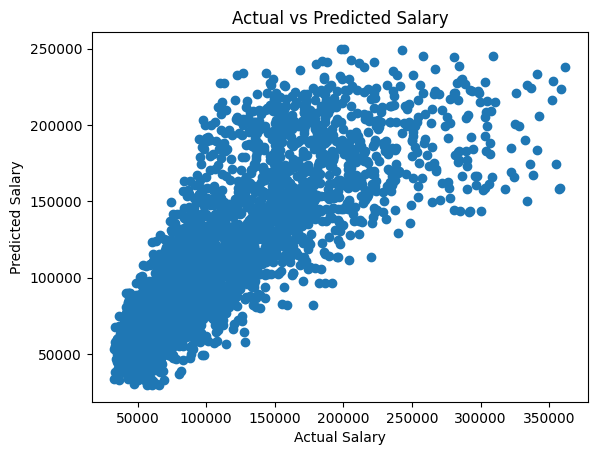

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()


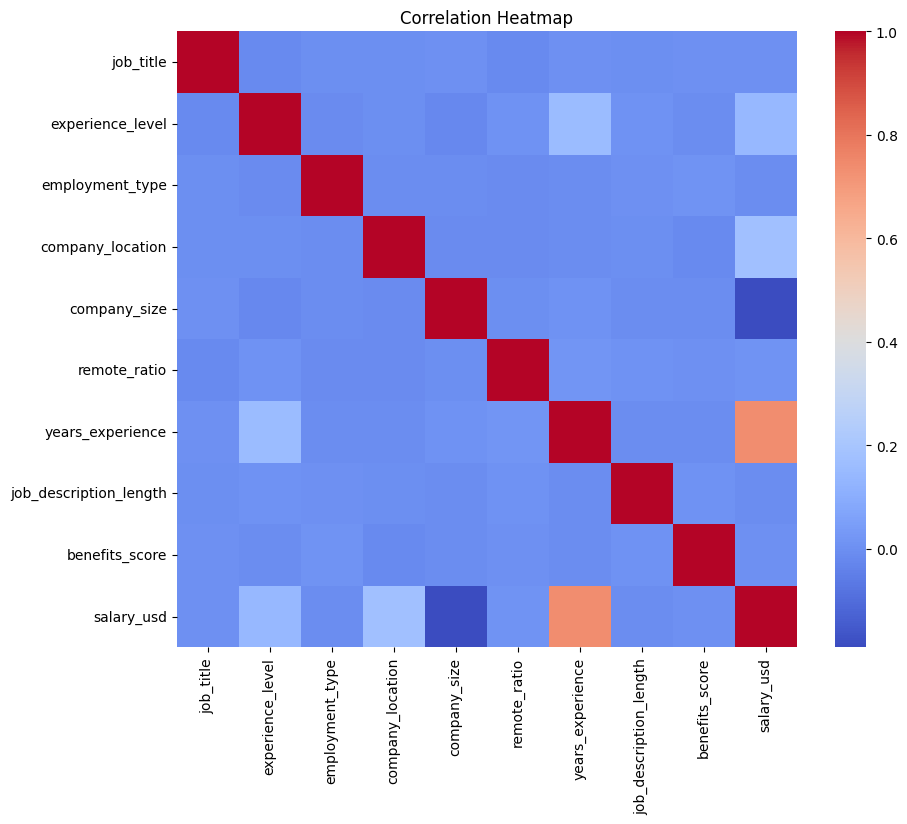

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2 Score:", rf_r2)


Random Forest MSE: 475088022.0942243
Random Forest R2 Score: 0.8697385605839962


In [19]:
import pandas as pd

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance_df


,Feature,Importance
6,years_experience,0.549098
3,company_location,0.243663
1,experience_level,0.065579
4,company_size,0.050249
7,job_description_length,0.029673
8,benefits_score,0.024868
0,job_title,0.020407
2,employment_type,0.009089
5,remote_ratio,0.007374


## Final Conclusion

In this project, we built a salary prediction model using the
Global AI Job Market dataset.

Two regression models were implemented:

1. Linear Regression
2. Random Forest Regressor

The Random Forest model performed significantly better with an
R² score of 0.87, meaning it explains approximately 87% of the
variance in salary data.

Feature importance analysis revealed that factors such as
years of experience, job role, and company size strongly
influence salary prediction.

This project successfully demonstrates:

- Data preprocessing
- Feature selection
- Regression modeling
- Model evaluation
- Model comparison

The model can further be improved using hyperparameter tuning
and advanced ensemble techniques.
